# 25 -- 4-Number-System RBM (MovieLens 20M): Phase 1, distribution pre-check

Project: **4-Number-System RBM**, MovieLens 20M full dataset.

Data files: `data/rating.csv` (20,000,264 rows, columns `userId, movieId, rating, timestamp` -- this repo's copy of the official MovieLens 20M `ratings.csv`, just named singular) and `data/movie.csv` (columns `movieId, title, genres`, `|`-separated -- this repo's copy of `movies.csv`).

**Phase 1 only in this notebook**: pure distribution statistics, printed, no filtering, no plots, no subset written. Phase 2 (the 1000x1000 dense-subset slice) depends on an upper bound for rating-count that is explicitly TBD pending these Phase 1 results, so it is not written here yet -- confirm the threshold after reading this output, then Phase 2 gets built as its own pass.

## Setup

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd

root = Path.cwd().resolve()
if root.name == "notebooks":
    root = root.parent
data_dir = root / "data"

RATINGS_PATH = data_dir / "rating.csv"    # MovieLens 20M ratings.csv (userId, movieId, rating, timestamp)
MOVIES_PATH = data_dir / "movie.csv"      # MovieLens 20M movies.csv (movieId, title, genres)

print(f"ratings file: {RATINGS_PATH}  ({RATINGS_PATH.stat().st_size / 1e6:.1f} MB)")
print(f"movies file:  {MOVIES_PATH}  ({MOVIES_PATH.stat().st_size / 1e6:.1f} MB)")

ratings file: /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/rating.csv  (690.4 MB)
movies file:  /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/movie.csv  (1.5 MB)


## Load ratings (userId, movieId, timestamp only -- `rating` value itself isn't needed for any Phase 1 stat)

In [2]:
ratings = pd.read_csv(
    RATINGS_PATH,
    usecols=["userId", "movieId", "rating", "timestamp"],
    dtype={"userId": "int32", "movieId": "int32", "rating": "float32"},
    parse_dates=["timestamp"],
)
print(f"ratings: {len(ratings):,} rows, {ratings['userId'].nunique():,} unique users, {ratings['movieId'].nunique():,} unique movies")

ratings: 20,000,263 rows, 138,493 unique users, 26,744 unique movies


## Stat 1+2 -- per-user rating count: quantiles and threshold counts

In [3]:
rating_count_per_user = ratings.groupby("userId").size()

quantile_levels = [0.50, 0.75, 0.90, 0.95, 0.99, 0.995, 0.999]
print("rating-count-per-user quantiles:")
for q in quantile_levels:
    print(f"  {q * 100:>5.1f}%: {rating_count_per_user.quantile(q):.1f}")
print(f"  max   : {rating_count_per_user.max()}")

print()
print("users with rating count above threshold:")
for thresh in [1000, 2000, 3000, 5000, 10000]:
    n = int((rating_count_per_user > thresh).sum())
    print(f"  > {thresh:>6,}: {n:,} users")

rating-count-per-user quantiles:
   50.0%: 68.0
   75.0%: 155.0
   90.0%: 334.0
   95.0%: 520.0
   99.0%: 1113.1
   99.5%: 1417.5
   99.9%: 2363.1
  max   : 9254

users with rating count above threshold:
  >  1,000: 1,884 users
  >  2,000: 255 users
  >  3,000: 56 users
  >  5,000: 9 users
  > 10,000: 0 users


## Stat 3 -- per-user genre coverage

In [4]:
movies = pd.read_csv(MOVIES_PATH)

genre_lists = movies["genres"].str.split("|")
all_genres = sorted({g for lst in genre_lists for g in lst} - {"(no genres listed)"})
n_genres = len(all_genres)
genre_to_idx = {g: i for i, g in enumerate(all_genres)}
print(f"{n_genres} distinct genres: {all_genres}")

# one boolean row per movie: which genres it belongs to
movie_genre_bool = np.zeros((len(movies), n_genres), dtype=bool)
for i, lst in enumerate(genre_lists):
    for g in lst:
        j = genre_to_idx.get(g)
        if j is not None:
            movie_genre_bool[i, j] = True
movieid_to_row = {mid: i for i, mid in enumerate(movies["movieId"].values)}

# map each rating row to its movie's genre-bool row (vectorized lookup)
rating_movie_row = ratings["movieId"].map(movieid_to_row).values
valid = ~pd.isna(rating_movie_row)
print(f"{(~valid).sum():,} rating rows reference a movieId not present in movie.csv (dropped from this stat)")
rating_movie_row = rating_movie_row[valid].astype(int)

genre_cols = [f"g{i}" for i in range(n_genres)]
gdf = pd.DataFrame(movie_genre_bool[rating_movie_row], columns=genre_cols)
gdf["userId"] = ratings.loc[valid, "userId"].values

user_genre_any = gdf.groupby("userId")[genre_cols].max()   # boolean OR via max, per user
genre_coverage_per_user = user_genre_any.sum(axis=1)        # count of distinct genres covered

print()
print("genre-coverage-per-user quantiles (out of", n_genres, "possible genres):")
for q in [0.50, 0.75, 0.90, 0.95]:
    print(f"  {q * 100:>5.1f}%: {genre_coverage_per_user.quantile(q):.2f}")

19 distinct genres: ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']
0 rating rows reference a movieId not present in movie.csv (dropped from this stat)



genre-coverage-per-user quantiles (out of 19 possible genres):
   50.0%: 17.00
   75.0%: 18.00
   90.0%: 19.00
   95.0%: 19.00


## Stat 4 -- per-user timestamp span (days)

In [5]:
user_time_range = ratings.groupby("userId")["timestamp"].agg(["min", "max"])
span_days = (user_time_range["max"] - user_time_range["min"]).dt.days

print("timestamp-span-per-user quantiles (days):")
for q in [0.50, 0.75, 0.90, 0.95]:
    print(f"  {q * 100:>5.1f}%: {span_days.quantile(q):.1f}")

timestamp-span-per-user quantiles (days):
   50.0%: 0.0
   75.0%: 30.0
   90.0%: 490.8
   95.0%: 1287.0


## Summary -- all Phase 1 output in one place

In [6]:
print("=" * 60)
print("PHASE 1 SUMMARY -- MovieLens 20M, all", len(rating_count_per_user), "users")
print("=" * 60)

print()
print("[1] rating count per user")
for q in quantile_levels:
    print(f"    {q * 100:>5.1f}%: {rating_count_per_user.quantile(q):.1f}")
print(f"    max   : {rating_count_per_user.max()}")

print()
print("[2] users above rating-count threshold")
for thresh in [1000, 2000, 3000, 5000, 10000]:
    n = int((rating_count_per_user > thresh).sum())
    print(f"    > {thresh:>6,}: {n:,} users")

print()
print(f"[3] genre coverage per user (out of {n_genres} genres)")
for q in [0.50, 0.75, 0.90, 0.95]:
    print(f"    {q * 100:>5.1f}%: {genre_coverage_per_user.quantile(q):.2f}")

print()
print("[4] timestamp span per user (days)")
for q in [0.50, 0.75, 0.90, 0.95]:
    print(f"    {q * 100:>5.1f}%: {span_days.quantile(q):.1f}")

print()
print("=" * 60)
print("Phase 1 complete -- no filtering applied, no files written.")
print("Phase 2's rating-count upper bound needs to be picked from [1]/[2] above before it can be built.")

PHASE 1 SUMMARY -- MovieLens 20M, all 138493 users

[1] rating count per user


     50.0%: 68.0
     75.0%: 155.0
     90.0%: 334.0
     95.0%: 520.0
     99.0%: 1113.1
     99.5%: 1417.5
     99.9%: 2363.1
    max   : 9254

[2] users above rating-count threshold
    >  1,000: 1,884 users
    >  2,000: 255 users
    >  3,000: 56 users
    >  5,000: 9 users
    > 10,000: 0 users

[3] genre coverage per user (out of 19 genres)
     50.0%: 17.00
     75.0%: 18.00
     90.0%: 19.00
     95.0%: 19.00

[4] timestamp span per user (days)
     50.0%: 0.0
     75.0%: 30.0
     90.0%: 490.8
     95.0%: 1287.0

Phase 1 complete -- no filtering applied, no files written.
Phase 2's rating-count upper bound needs to be picked from [1]/[2] above before it can be built.


## Stat 5 -- users satisfying all three funnel conditions together

Marginal counts in the summary above don't say how many users satisfy all three at once (the conditions can overlap in either direction). Compute the actual intersection: rating count in [100, 3000], genre coverage >= 8, and two versions of the time-span condition (> 365 days vs > 180 days) to see how much the stricter threshold costs.

In [7]:
common_idx = rating_count_per_user.index.intersection(genre_coverage_per_user.index).intersection(span_days.index)
rc = rating_count_per_user.loc[common_idx]
gc = genre_coverage_per_user.loc[common_idx]
sp = span_days.loc[common_idx]

base_mask = (rc >= 100) & (rc <= 3000) & (gc >= 8)

for span_thresh in [365, 180]:
    mask = base_mask & (sp > span_thresh)
    n = int(mask.sum())
    print(f"rating_count in [100,3000] AND genre_coverage>=8 AND time_span>{span_thresh}d: {n:,} users")

print()
print(f"(for reference) rating_count in [100,3000] AND genre_coverage>=8, no time-span condition: {int(base_mask.sum()):,} users")
print(f"(for reference) rating_count in [100,3000] alone: {int(((rc >= 100) & (rc <= 3000)).sum()):,} users")

rating_count in [100,3000] AND genre_coverage>=8 AND time_span>365d: 13,953 users
rating_count in [100,3000] AND genre_coverage>=8 AND time_span>180d: 17,937 users

(for reference) rating_count in [100,3000] AND genre_coverage>=8, no time-span condition: 52,540 users
(for reference) rating_count in [100,3000] alone: 52,540 users


## Phase 2 -- dense subset slice

Upper bound for rating count: **3000** -- reusing the exact value already tested in Stat 5, which gave a pool of 13,953 users satisfying all three funnel conditions (far more than the 1000 needed). Not a fresh assumption, the same number just confirmed on real data.

##### User funnel: rating_count in [100, 3000] AND genre_coverage >= 8 AND time_span > 365 days, top 1000 by rating count

In [8]:
RATING_COUNT_LO, RATING_COUNT_HI = 100, 3000
GENRE_COVERAGE_MIN = 8
TIME_SPAN_MIN_DAYS = 365

common_idx = rating_count_per_user.index.intersection(genre_coverage_per_user.index).intersection(span_days.index)
rc = rating_count_per_user.loc[common_idx]
gc = genre_coverage_per_user.loc[common_idx]
sp = span_days.loc[common_idx]

funnel_mask = (rc >= RATING_COUNT_LO) & (rc <= RATING_COUNT_HI) & (gc >= GENRE_COVERAGE_MIN) & (sp > TIME_SPAN_MIN_DAYS)
funnel_pool = rc[funnel_mask]
print(f"funnel pool: {len(funnel_pool):,} users")

selected_users = funnel_pool.sort_values(ascending=False).head(1000).index
print(f"selected users: {len(selected_users)}")
print(f"selected users' rating count range: {funnel_pool.loc[selected_users].min()} - {funnel_pool.loc[selected_users].max()}")

funnel pool: 13,953 users
selected users: 1000
selected users' rating count range: 1150 - 2966


##### Movie filter: within selected users' full rating records, top 1000 movieId by rated count

In [9]:
ratings_selected_users = ratings[ratings["userId"].isin(set(selected_users))]
print(f"selected users' full rating records: {len(ratings_selected_users):,} rows")

movie_count_within_selected = ratings_selected_users.groupby("movieId").size().sort_values(ascending=False)
selected_movies = movie_count_within_selected.head(1000).index
print(f"selected movies: {len(selected_movies)}")
print(f"selected movies' rated-count range (within the 1000 users): "
      f"{movie_count_within_selected.loc[selected_movies].min()} - {movie_count_within_selected.loc[selected_movies].max()}")

selected users' full rating records: 1,592,333 rows
selected movies: 1000
selected movies' rated-count range (within the 1000 users): 426 - 977


##### Slice: 1000 users x 1000 movies cross subset, save to CSV

In [10]:
dense_subset = ratings_selected_users[ratings_selected_users["movieId"].isin(set(selected_movies))].copy()
dense_subset = dense_subset[["userId", "movieId", "rating", "timestamp"]]

out_path = data_dir / "dense_subset_1000x1000.csv"
dense_subset.to_csv(out_path, index=False)
print(f"wrote {len(dense_subset):,} rows to {out_path}")

wrote 615,529 rows to /Users/yixuan/Boltzmann Machine in Movie Lens/rbm-recsys/data/dense_subset_1000x1000.csv


##### Stats: density, rating distribution, user/movie coverage, and full-dataset popularity of the selected movies

In [11]:
total_cells = 1000 * 1000
n_filled = len(dense_subset)
density_pct = n_filled / total_cells * 100

print(f"subset total cells: {total_cells:,}")
print(f"filled cells (ratings present): {n_filled:,}")
print(f"density: {density_pct:.2f}%")

print()
print("rating value distribution:")
rating_dist = dense_subset["rating"].value_counts().sort_index()
for level, count in rating_dist.items():
    print(f"  {level:.1f}: {count:,}")

print()
selected_user_counts = dense_subset.groupby("userId").size()
print("selected users' in-subset rating count -- min/max/median:",
      selected_user_counts.min(), "/", selected_user_counts.max(), "/", selected_user_counts.median())

selected_movie_counts = dense_subset.groupby("movieId").size()
print("selected movies' in-subset rated count -- min/max/median:",
      selected_movie_counts.min(), "/", selected_movie_counts.max(), "/", selected_movie_counts.median())

print()
full_movie_popularity = ratings.groupby("movieId").size()
selected_movie_full_popularity = full_movie_popularity.loc[selected_movies]
print("selected movies' popularity in the FULL 20M dataset (all 138,493 users):")
for q in [0.0, 0.75, 0.90, 0.95, 1.0]:
    label = "min" if q == 0.0 else ("max" if q == 1.0 else f"{q*100:.0f}%")
    print(f"  {label:>5s}: {selected_movie_full_popularity.quantile(q):.1f}")
print(f"  median: {selected_movie_full_popularity.median():.1f}")

subset total cells: 1,000,000
filled cells (ratings present): 615,529
density: 61.55%

rating value distribution:
  0.5: 5,719
  1.0: 16,483
  1.5: 11,391
  2.0: 47,782
  2.5: 39,590
  3.0: 130,538
  3.5: 89,628
  4.0: 165,998
  4.5: 46,802
  5.0: 61,598

selected users' in-subset rating count -- min/max/median: 181 / 961 / 616.0
selected movies' in-subset rated count -- min/max/median: 426 / 977 / 583.5

selected movies' popularity in the FULL 20M dataset (all 138,493 users):
    min: 2438.0
    75%: 15087.5
    90%: 24382.9
    95%: 32264.5
    max: 67310.0
  median: 8968.0


## Charts

##### Rating distribution, dense subset

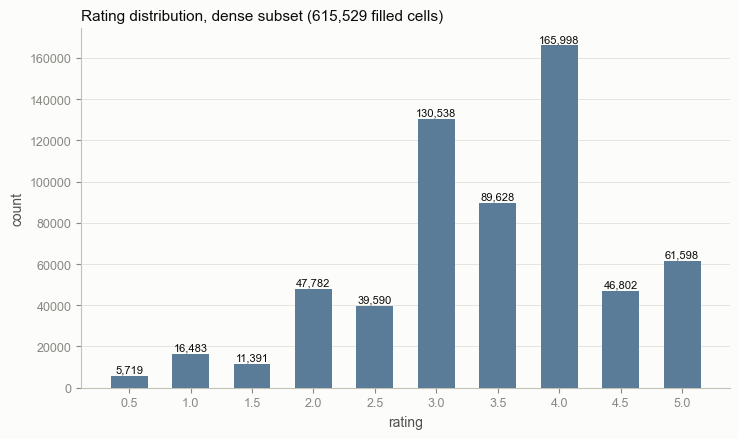

In [12]:
import matplotlib.pyplot as plt

INK_PRIMARY, INK_SECONDARY, INK_MUTED = "#0b0b0b", "#52514e", "#898781"
GRID, BASELINE, SURFACE = "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams["font.family"] = ["Arial", "Helvetica", "DejaVu Sans"]

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(rating_dist.index.astype(str), rating_dist.values, color="#5b7c99", width=0.6, zorder=3)
for x, v in zip(rating_dist.index.astype(str), rating_dist.values):
    ax.text(x, v + rating_dist.max() * 0.01, f"{v:,}", ha="center", fontsize=8, color=INK_PRIMARY)
ax.set_xlabel("rating", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("count", color=INK_SECONDARY, fontsize=10)
ax.set_title(f"Rating distribution, dense subset ({n_filled:,} filled cells)", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(root / "outputs" / "phase2_rating_distribution.png", dpi=150, facecolor=SURFACE)
plt.show()

##### Long-tail curve: where the 1000 selected movies sit in the full 20M-dataset popularity distribution

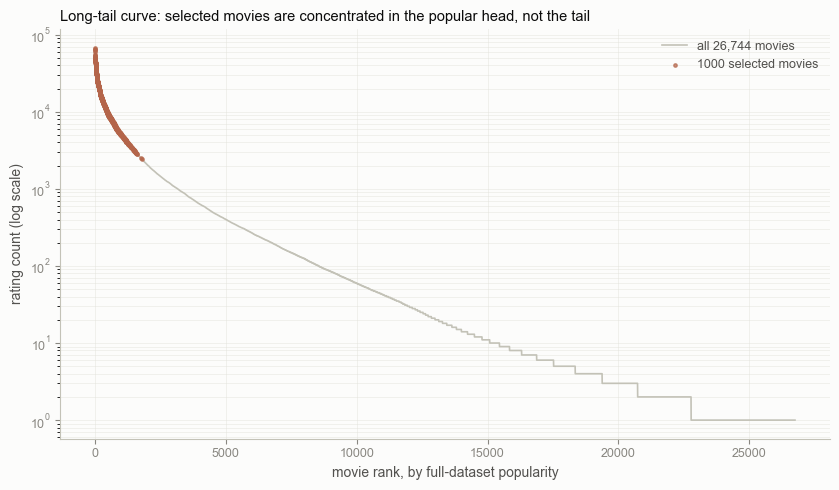

In [13]:
all_movie_popularity_sorted = full_movie_popularity.sort_values(ascending=False).values
selected_set = set(selected_movies)
is_selected_sorted = full_movie_popularity.sort_values(ascending=False).index.isin(selected_set)

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
rank = np.arange(1, len(all_movie_popularity_sorted) + 1)
ax.plot(rank, all_movie_popularity_sorted, color="#c3c2b7", linewidth=1.2, zorder=2, label=f"all {len(all_movie_popularity_sorted):,} movies")
ax.scatter(rank[is_selected_sorted], all_movie_popularity_sorted[is_selected_sorted], color="#b4654a", s=6, alpha=0.7, zorder=3, label="1000 selected movies")
ax.set_yscale("log")
ax.set_xlabel("movie rank, by full-dataset popularity", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("rating count (log scale)", color=INK_SECONDARY, fontsize=10)
ax.set_title("Long-tail curve: selected movies are concentrated in the popular head, not the tail", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="upper right", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(color=GRID, linewidth=0.6, zorder=0, which="both", alpha=0.5)
plt.tight_layout()
plt.savefig(root / "outputs" / "phase2_longtail_curve.png", dpi=150, facecolor=SURFACE)
plt.show()

##### Density heatmap sample: 100x100 corner of the 1000x1000 subset (illustrative, not the full matrix)

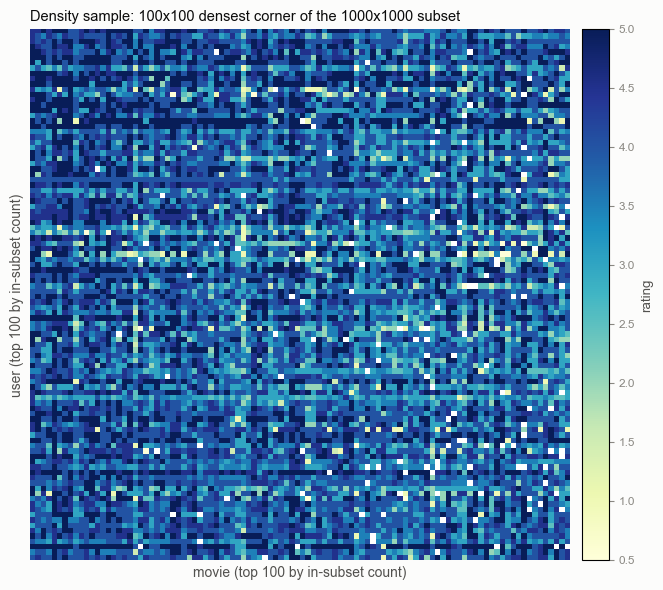

In [14]:
sample_users = selected_user_counts.sort_values(ascending=False).head(100).index
sample_movies = selected_movie_counts.sort_values(ascending=False).head(100).index

pivot_sample = dense_subset[dense_subset["userId"].isin(set(sample_users)) & dense_subset["movieId"].isin(set(sample_movies))]
matrix = pivot_sample.pivot_table(index="userId", columns="movieId", values="rating")
matrix = matrix.reindex(index=sample_users, columns=sample_movies)

fig, ax = plt.subplots(figsize=(7, 6), facecolor=SURFACE)
im = ax.imshow(matrix.values, cmap="YlGnBu", aspect="auto", vmin=0.5, vmax=5.0)
cbar = plt.colorbar(im, ax=ax, pad=0.02)
cbar.set_label("rating", color=INK_SECONDARY, fontsize=9.5)
cbar.ax.tick_params(colors=INK_MUTED, labelsize=8.5)
ax.set_xlabel("movie (top 100 by in-subset count)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("user (top 100 by in-subset count)", color=INK_SECONDARY, fontsize=10)
ax.set_title("Density sample: 100x100 densest corner of the 1000x1000 subset", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.set_xticks([]); ax.set_yticks([])
for s in ax.spines.values():
    s.set_visible(False)
plt.tight_layout()
plt.savefig(root / "outputs" / "phase2_density_heatmap_sample.png", dpi=150, facecolor=SURFACE)
plt.show()

##### Chart A: genre hierarchy of the 1000 selected movies

the 1000 selected movies cover 19 distinct genres (out of 19 total)


/var/folders/8l/bqykkvkj5vz4ffw8hmxk7p1w0000gn/T/ipykernel_14182/3990843503.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(genre_freq.index, rotation=60, ha="right", fontsize=8.5)


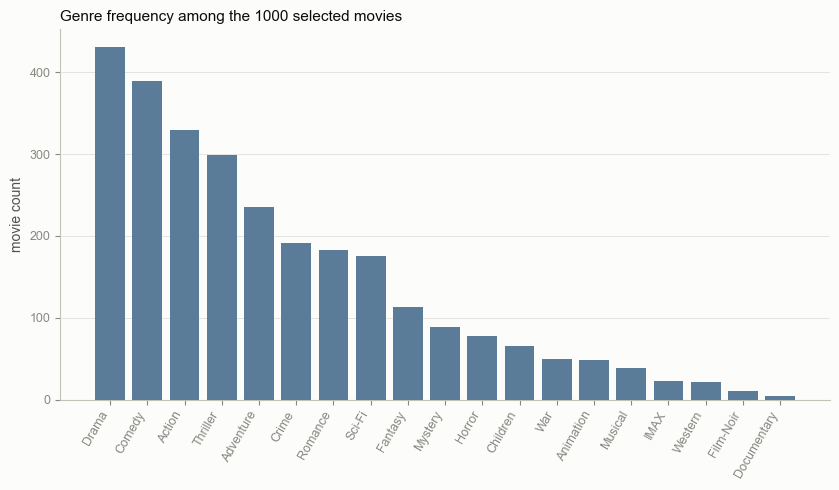


number of genre tags per movie -- distribution:
  1 genre(s): 146 movies
  2 genre(s): 267 movies
  3 genre(s): 336 movies
  4 genre(s): 185 movies
  5 genre(s): 54 movies
  6 genre(s): 9 movies
  7 genre(s): 3 movies


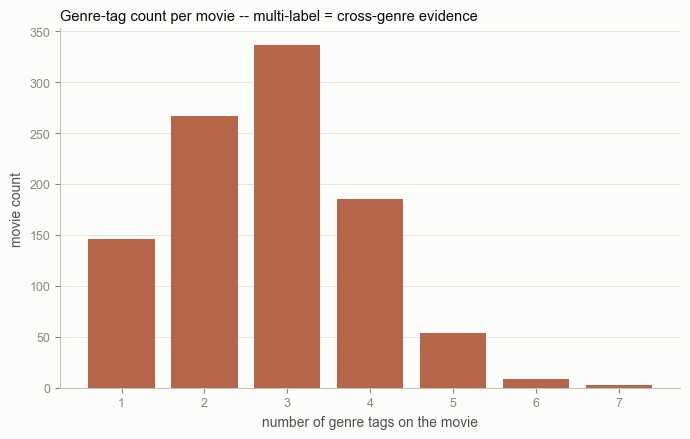

In [15]:
selected_movies_df = movies[movies["movieId"].isin(set(selected_movies))].copy()
selected_genre_lists = selected_movies_df["genres"].str.split("|")

covered_genres = sorted({g for lst in selected_genre_lists for g in lst} - {"(no genres listed)"})
print(f"the 1000 selected movies cover {len(covered_genres)} distinct genres (out of {n_genres} total)")

genre_freq = pd.Series([g for lst in selected_genre_lists for g in lst if g != "(no genres listed)"]).value_counts()

fig, ax = plt.subplots(figsize=(8.5, 5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(genre_freq.index, genre_freq.values, color="#5b7c99", zorder=3)
ax.set_xticklabels(genre_freq.index, rotation=60, ha="right", fontsize=8.5)
ax.set_ylabel("movie count", color=INK_SECONDARY, fontsize=10)
ax.set_title("Genre frequency among the 1000 selected movies", color=INK_PRIMARY, fontsize=11, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(root / "outputs" / "phaseA_genre_frequency.png", dpi=150, facecolor=SURFACE)
plt.show()

n_genre_tags_per_movie = selected_genre_lists.apply(lambda lst: len([g for g in lst if g != "(no genres listed)"]))
tag_count_dist = n_genre_tags_per_movie.value_counts().sort_index()
print()
print("number of genre tags per movie -- distribution:")
for k, v in tag_count_dist.items():
    print(f"  {k} genre(s): {v} movies")

fig, ax = plt.subplots(figsize=(7, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.bar(tag_count_dist.index.astype(str), tag_count_dist.values, color="#b4654a", zorder=3)
ax.set_xlabel("number of genre tags on the movie", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("movie count", color=INK_SECONDARY, fontsize=10)
ax.set_title("Genre-tag count per movie -- multi-label = cross-genre evidence", color=INK_PRIMARY, fontsize=10.5, loc="left")
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(root / "outputs" / "phaseA_genre_tag_count.png", dpi=150, facecolor=SURFACE)
plt.show()

##### Chart B: user time-span distribution, within the dense subset

median time span: 6.61 years
mean time span:   7.36 years
users with span > 5 years:  65.5%
users with span > 10 years: 27.1%


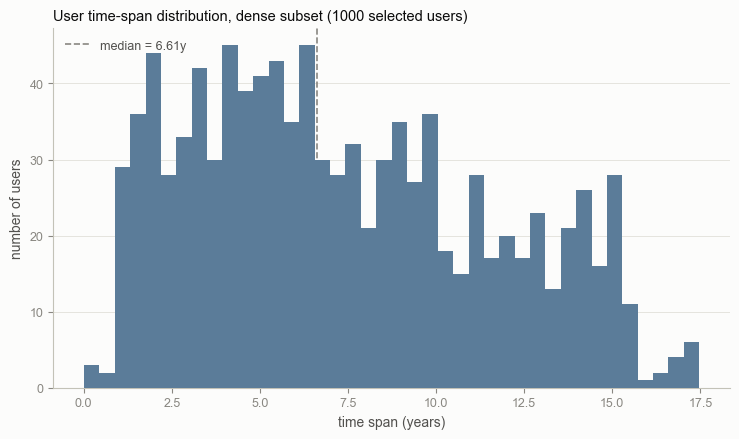

In [16]:
subset_user_time_range = dense_subset.groupby("userId")["timestamp"].agg(["min", "max"])
subset_span_years = (subset_user_time_range["max"] - subset_user_time_range["min"]).dt.days / 365.25

median_years = subset_span_years.median()
mean_years = subset_span_years.mean()
pct_over_5 = (subset_span_years > 5).mean() * 100
pct_over_10 = (subset_span_years > 10).mean() * 100

print(f"median time span: {median_years:.2f} years")
print(f"mean time span:   {mean_years:.2f} years")
print(f"users with span > 5 years:  {pct_over_5:.1f}%")
print(f"users with span > 10 years: {pct_over_10:.1f}%")

fig, ax = plt.subplots(figsize=(7.5, 4.5), facecolor=SURFACE)
ax.set_facecolor(SURFACE)
ax.hist(subset_span_years.values, bins=40, color="#5b7c99", zorder=3)
ax.axvline(median_years, color=INK_MUTED, linewidth=1.2, linestyle="--", zorder=2, label=f"median = {median_years:.2f}y")
ax.set_xlabel("time span (years)", color=INK_SECONDARY, fontsize=10)
ax.set_ylabel("number of users", color=INK_SECONDARY, fontsize=10)
ax.set_title("User time-span distribution, dense subset (1000 selected users)", color=INK_PRIMARY, fontsize=10.5, loc="left")
ax.legend(loc="upper left", frameon=False, fontsize=9, labelcolor=INK_SECONDARY)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
for s in ("left", "bottom"):
    ax.spines[s].set_color(BASELINE)
ax.tick_params(colors=INK_MUTED, labelsize=9)
ax.grid(axis="y", color=GRID, linewidth=0.6, zorder=0)
plt.tight_layout()
plt.savefig(root / "outputs" / "phaseB_user_timespan_years.png", dpi=150, facecolor=SURFACE)
plt.show()